In [1]:
!pip install nicaviz

In [2]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from kagglehub import KaggleDatasetAdapter

sns.set_theme(style="whitegrid", context="notebook")


def _distplot_compat(a, ax=None, **kwargs):
    kde_kws = kwargs.pop("kde_kws", {}) or {}
    if ax is None:
        ax = plt.gca()
    sns.histplot(a, ax=ax, kde=True, stat="density", kde_kws=kde_kws, **kwargs)
    return ax


if not hasattr(sns, "distplot"):
    sns.distplot = _distplot_compat

import nicaviz  # noqa: F401 — registers `DataFrame.nica` accessor


In [3]:
DATA_SLUG = "nicapotato/osrs-money-makers"
GUIDES_FILE = "input_output.parquet"
METHODS_FILE = "methods.parquet"


def load_parquet(file_path: str) -> pd.DataFrame:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        matches = sorted(
            kaggle_root.rglob(file_path),
            key=lambda p: p.stat().st_size,
            reverse=True,
        )
        if matches:
            print(f"Kaggle input: {matches[0]}")
            return pd.read_parquet(matches[0])

    local = Path("data") / file_path
    if local.exists():
        print(f"Local: {local.resolve()}")
        return pd.read_parquet(local)

    df = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        DATA_SLUG,
        file_path,
    )
    print(f"kagglehub: {DATA_SLUG}/{file_path}")
    return df


guides = load_parquet(GUIDES_FILE)
methods = load_parquet(METHODS_FILE)

print("Guides:", guides.shape[0], "rows ×", guides.shape[1], "cols")
print("Methods:", methods.shape[0], "rows ×", methods.shape[1], "cols")

df = guides.merge(methods, on="method_id", how="left", validate="m:1")
print("Joined:", df.shape[0], "rows ×", df.shape[1], "cols")
print("First 5 records:")
display(df.head())


Kaggle input: /kaggle/input/datasets/nicapotato/osrs-money-makers/input_output.parquet
Kaggle input: /kaggle/input/datasets/nicapotato/osrs-money-makers/methods.parquet
Guides: 6085 rows × 8 cols
Methods: 497 rows × 6 cols
Joined: 6085 rows × 13 cols
First 5 records:


,line_id,method_id,io_type,wiki_slug,item_name,item_id,qty_per_completion,first_scraped_at,method_name,method_url,categories,intensity,is_members
0,00041c3f15367d9a,f99659b0f3c4bd1d,output,Coal,Coal,453.0,1.5625,2026-05-26 10:10:59.564653+00:00,Killing Dagannoth Kings (Rex only),/w/Money_making_guide/Killing_Dagannoth_Kings_...,"[Combat, Mid]",Low,True
1,00050a2054b06a13,28e8a3206207cf16,output,Blood_rune,Blood rune,565.0,22.1600,2026-05-26 10:10:59.564653+00:00,Killing Phosani's Nightmare,/w/Money_making_guide/Killing_Phosani%27s_Nigh...,"[Combat, High]",High,True
2,0006f80d8e462da3,0ca79fb1ab95cb3b,output,Grimy_ranarr_weed,Grimy ranarr weed,207.0,3.1779,2026-05-26 10:10:59.564653+00:00,Theatre of Blood,/w/Money_making_guide/Theatre_of_Blood,"[Combat, High]",High,True
3,00325b1ff02e1438,04b438be0c3e32d7,input,Grimy_avantoe,Grimy avantoe,211.0,1.0000,2026-05-26 10:10:59.564653+00:00,Cleaning grimy avantoe,/w/Money_making_guide/Cleaning_grimy_avantoe,"[Skilling, Herblore]",High,True
4,0033ad0c451951dc,ea068413dc9ea0cd,output,Chaos_rune,Chaos rune,562.0,2.5000,2026-05-26 10:10:59.564653+00:00,Killing Lizardman Shamans (Canyon),/w/Money_making_guide/Killing_Lizardman_Shaman...,"[Combat, High]",Moderate,True


In [4]:
display(df.sample(min(5, len(df)), random_state=42))
display(df.dtypes.to_frame("dtype"))
display(df[["qty_per_completion"]].describe().T)

ID_COLS = ["line_id", "method_id", "item_id"]
CAT_COLS = ["io_type", "wiki_slug", "item_name", "method_name", "method_url", "intensity"]
BOOL_COLS = ["is_members"]
NUM_COLS = ["qty_per_completion"]

# Primary category tag (first path segment) for stratified plots
df["primary_category"] = df["categories"].apply(
    lambda cats: cats[0] if isinstance(cats, (list, tuple)) and len(cats) else "Unknown"
)

method_stats = (
    df.groupby("method_id", as_index=False)
    .agg(
        n_lines=("line_id", "count"),
        n_inputs=("io_type", lambda s: (s == "input").sum()),
        n_outputs=("io_type", lambda s: (s == "output").sum()),
    )
)
input_qty = (
    df.loc[df["io_type"] == "input"]
    .groupby("method_id")["qty_per_completion"]
    .sum()
    .rename("total_input_qty")
)
method_stats = method_stats.merge(input_qty, on="method_id", how="left").fillna({"total_input_qty": 0})
method_stats = method_stats.merge(
    methods.assign(
        primary_category=methods["categories"].apply(
            lambda cats: cats[0] if isinstance(cats, (list, tuple)) and len(cats) else "Unknown"
        )
    )[["method_id", "method_name", "intensity", "is_members", "primary_category"]],
    on="method_id",
    how="left",
)

print(f"{df['method_id'].nunique()} distinct methods; {df['io_type'].nunique()} I/O types")


,line_id,method_id,io_type,wiki_slug,item_name,item_id,qty_per_completion,first_scraped_at,method_name,method_url,categories,intensity,is_members
3460,9104e4644a7f3600,216011667d5e0ac4,input,Raw_shark,Raw shark,383.0,1.000000,2026-05-26 10:10:59.564653+00:00,Cooking raw sharks,/w/Money_making_guide/Cooking_raw_sharks,"[Skilling, Cooking]",Low,True
296,0c7196bf198dddda,0d93452f84e54da2,output,Dragonstone_ring,Dragonstone ring,1645.0,0.009346,2026-05-26 10:10:59.564653+00:00,Killing the Thermonuclear smoke devil,/w/Money_making_guide/Killing_the_Thermonuclea...,"[Combat, High]",High,True
3306,89f10081ffc3d280,2ac1bd90e06fc03b,output,Rune_longsword,Rune longsword,1303.0,0.015873,2026-05-26 10:10:59.564653+00:00,Killing zombie pirates (Max efficiency),/w/Money_making_guide/Killing_zombie_pirates_(...,"[Combat, Low]",High,True
254,0a800682543c19ff,292f9f4285131e86,input,Runite_ore,Runite ore,451.0,1.000000,2026-05-26 10:10:59.564653+00:00,Smelting runite bars,/w/Money_making_guide/Smelting_runite_bars,"[Skilling, Smithing]",Low,False
964,272b43003caa4c34,892595a86c406f8e,output,Seercull,Seercull,6724.0,0.007812,2026-05-26 10:10:59.564653+00:00,Killing Dagannoth Kings (Solo tribrid),/w/Money_making_guide/Killing_Dagannoth_Kings_...,"[Combat, High]",Moderate,True


,dtype
line_id,object
method_id,object
io_type,object
wiki_slug,object
item_name,object
item_id,float64
qty_per_completion,float64
first_scraped_at,"datetime64[us, UTC]"
method_name,object
method_url,object


,count,mean,std,min,25%,50%,75%,max
qty_per_completion,6085.0,177.759098,2805.202037,0.000002,0.029326,0.5,2.884615,80000.0


497 distinct methods; 2 I/O types


In [5]:
cat_view = df[["io_type", "intensity", "primary_category", "is_members"]].copy()
cat_view["is_members"] = cat_view["is_members"].map({True: "Members", False: "Free-to-play"})
display(cat_view.nica.categorical_describe())


Dataframe Dimension: 6085 Rows, 4 Columns


,Unique,Missing,dtype,ValCount 1,Occ,ValCount 2,Occ,ValCount 3,Occ,ValCount 4,Occ,ValCount 5,Occ
Column,,,,,,,,,,,,,
io_type,2,0,object,output,4761,input,1324.0,NaN,NaN,NaN,NaN,NaN,NaN
intensity,3,0,object,High,3555,Moderate,1429.0,Low,1101.0,NaN,NaN,NaN,NaN
primary_category,1,0,object,Unknown,6085,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_members,2,0,object,Members,5698,Free-to-play,387.0,NaN,NaN,NaN,NaN,NaN,NaN


/tmp/ipykernel_16/4062303992.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=ax, palette="deep")
/tmp/ipykernel_16/4062303992.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=ax, palette="deep")
/tmp/ipykernel_16/4062303992.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=ax, palette="deep")
/tmp/ipykernel_16/4062303992.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. As

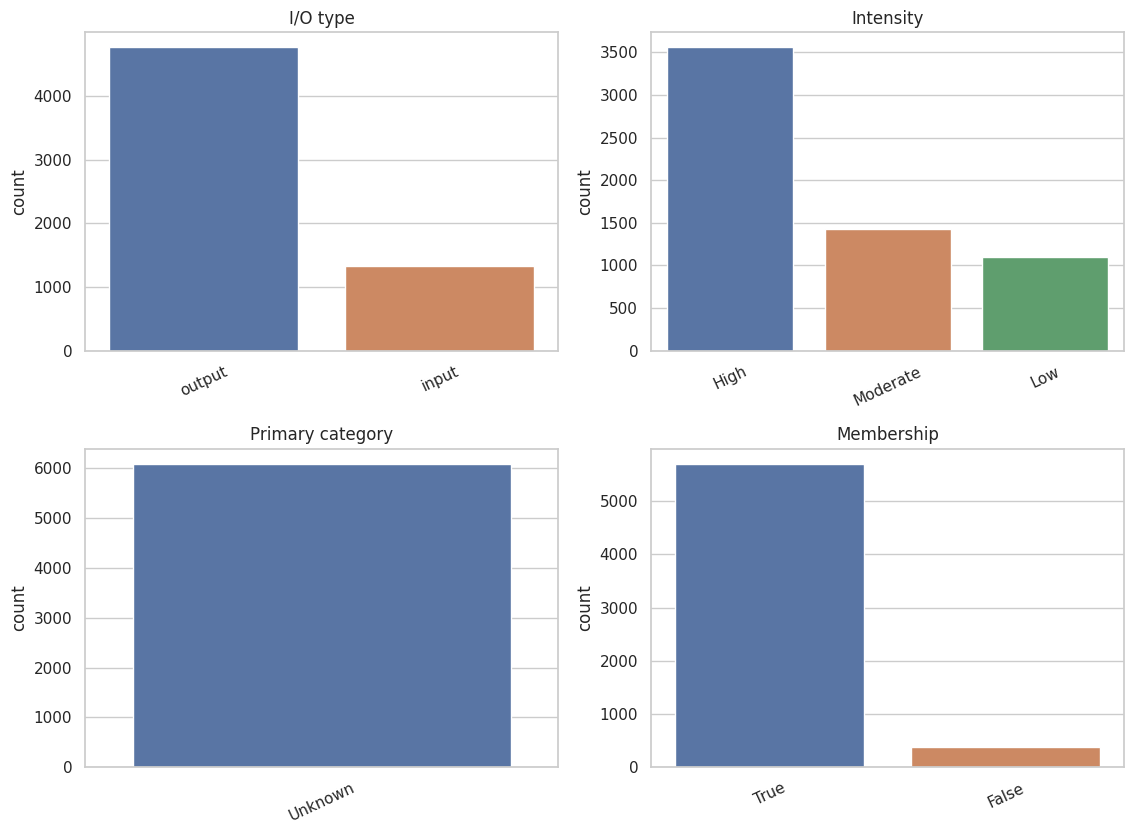

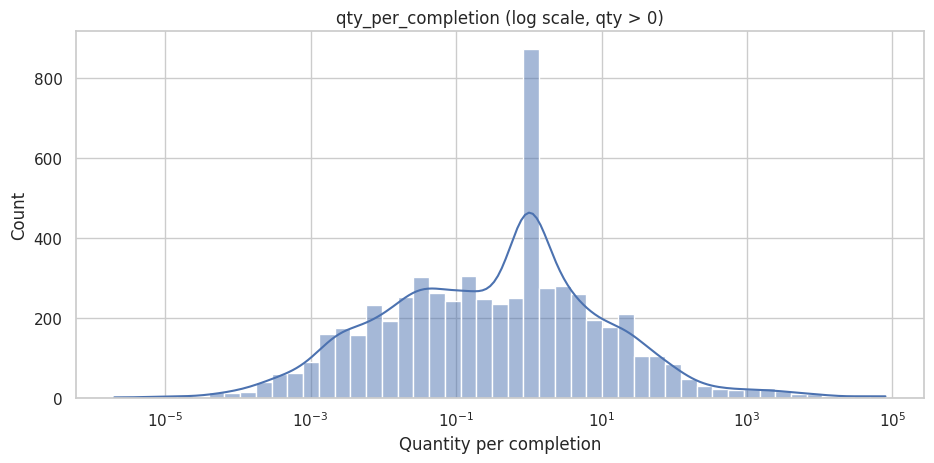

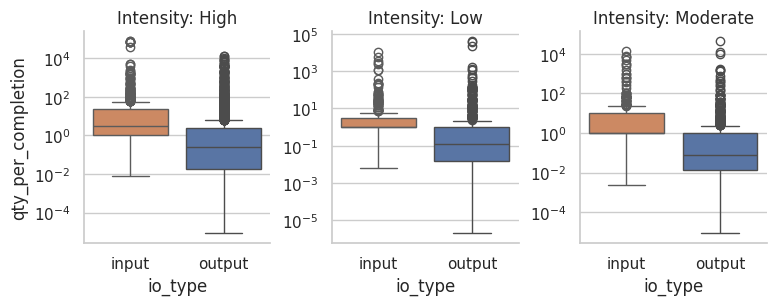

/tmp/ipykernel_16/4062303992.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lines_per_method.values, y=lines_per_method.index, ax=ax, palette="Blues_r")


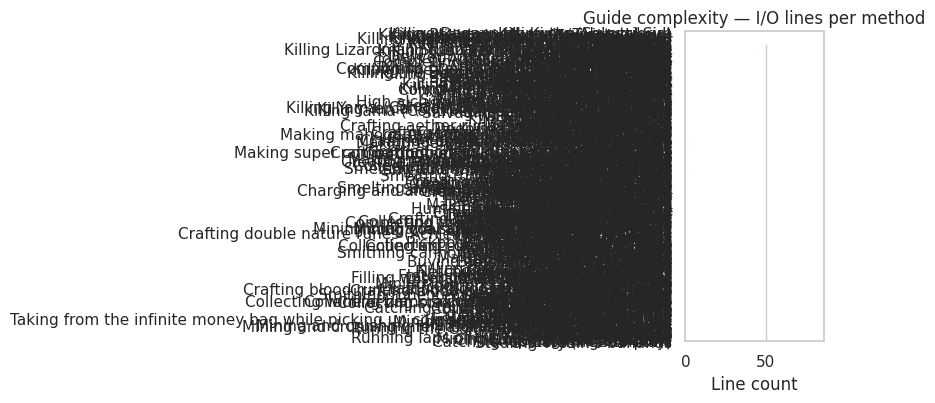

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.5))
for ax, col, title in zip(
    axes.ravel(),
    ["io_type", "intensity", "primary_category", "is_members"],
    ["I/O type", "Intensity", "Primary category", "Membership"],
):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax, palette="deep")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

# qty distribution — log x for wide GP/item ranges
fig, ax = plt.subplots(figsize=(9.5, 4.8))
positive_qty = df.loc[df["qty_per_completion"] > 0, "qty_per_completion"]
sns.histplot(positive_qty, log_scale=True, kde=True, ax=ax)
ax.set_title("qty_per_completion (log scale, qty > 0)")
ax.set_xlabel("Quantity per completion")
plt.tight_layout()
plt.show()

# FacetGrid: qty by io_type across intensity strata
plot_df = df[df["qty_per_completion"] > 0].copy()
g = sns.FacetGrid(
    plot_df,
    col="intensity",
    hue="io_type",
    col_order=sorted(plot_df["intensity"].unique()),
    height=3.2,
    aspect=1.05,
    sharex=False,
    sharey=False,
)
g.map_dataframe(sns.boxplot, y="qty_per_completion", x="io_type", order=["input", "output"])
g.set(yscale="log")
g.set_titles(col_template="Intensity: {col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=0)
if g._legend is not None:
    g._legend.set_bbox_to_anchor((1.02, 0.98))
    g._legend.set_loc("upper left")
plt.subplots_adjust(top=0.88, right=0.78)
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 4.2))
lines_per_method = df.groupby("method_name")["line_id"].count().sort_values(ascending=False)
sns.barplot(x=lines_per_method.values, y=lines_per_method.index, ax=ax, palette="Blues_r")
ax.set_title("Guide complexity — I/O lines per method")
ax.set_xlabel("Line count")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


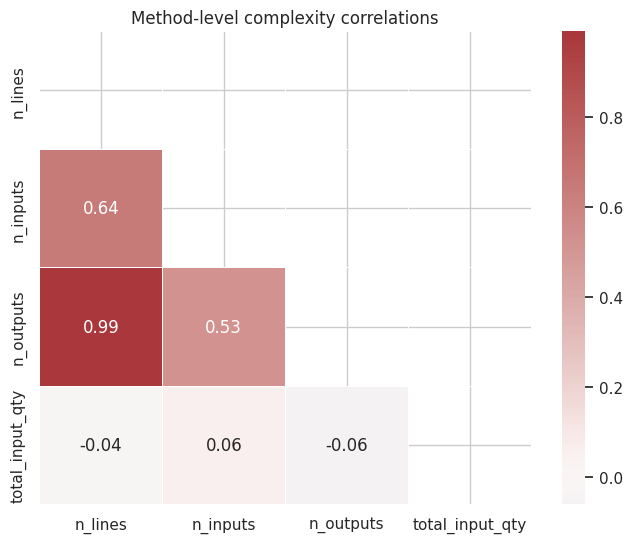

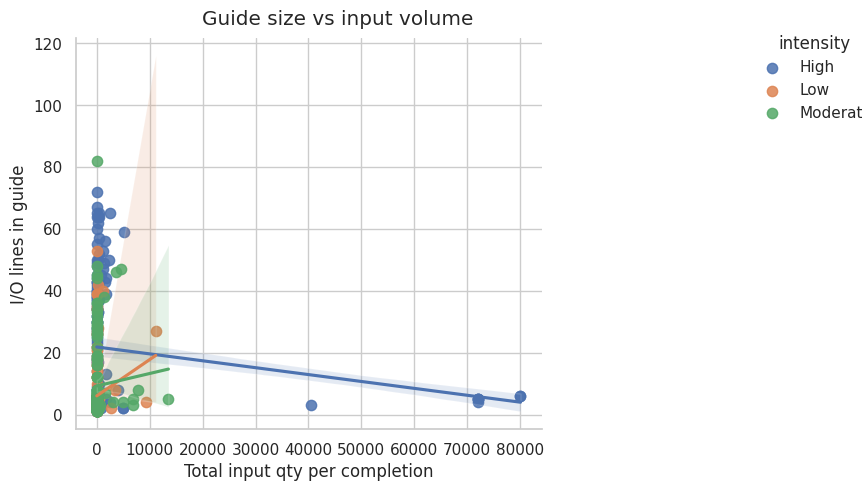

In [7]:
# Method-level correlation matrix
method_corr = method_stats[["n_lines", "n_inputs", "n_outputs", "total_input_qty"]].corr()
fig, ax = plt.subplots(figsize=(6.8, 5.6))
mask = np.triu(np.ones_like(method_corr, dtype=bool))
sns.heatmap(
    method_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    linewidths=0.4,
    ax=ax,
)
ax.set_title("Method-level complexity correlations")
plt.tight_layout()
plt.show()

g_lm = sns.lmplot(
    data=method_stats,
    x="total_input_qty",
    y="n_lines",
    hue="intensity",
    height=4.8,
    aspect=1.25,
    fit_reg=True,
    scatter_kws={"alpha": 0.85, "s": 55},
)
g_lm.set_axis_labels("Total input qty per completion", "I/O lines in guide")
g_lm.fig.suptitle("Guide size vs input volume", y=1.02)
if g_lm._legend is not None:
    g_lm._legend.set_bbox_to_anchor((1.02, 0.98))
    g_lm._legend.set_loc("upper left")
plt.subplots_adjust(right=0.78)
plt.show()


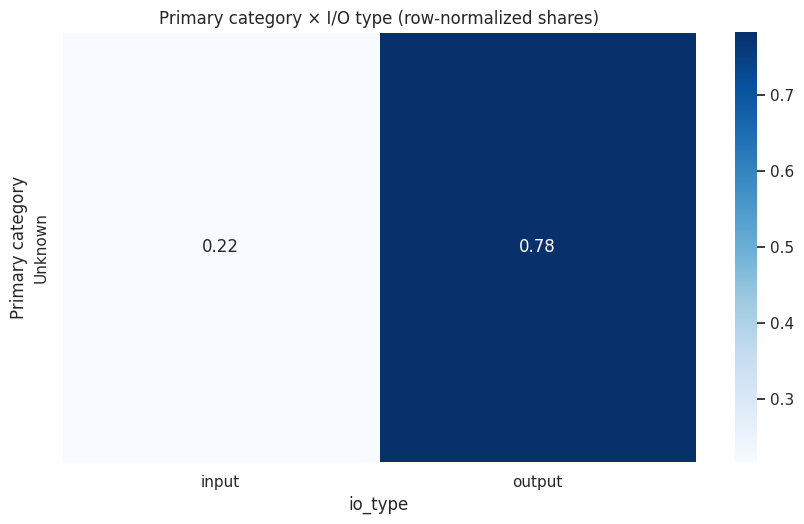

io_type,input,output
primary_category,,
Unknown,0.218,0.782


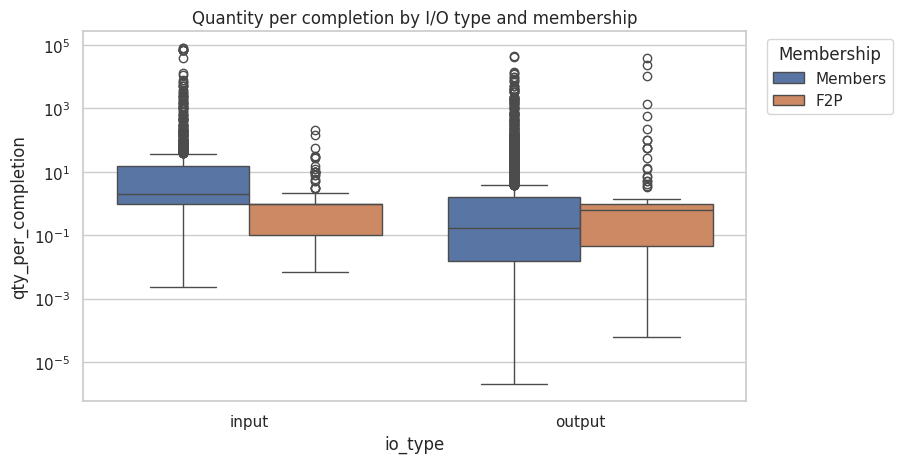

In [8]:
ct = pd.crosstab(df["primary_category"], df["io_type"], normalize="index")
fig, ax = plt.subplots(figsize=(8.8, 5.4))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues", linewidths=0.4, ax=ax)
ax.set_title("Primary category × I/O type (row-normalized shares)")
ax.set_ylabel("Primary category")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(ct.style.format("{:.3f}").background_gradient(cmap="Blues", axis=None))

fig, ax = plt.subplots(figsize=(9.2, 4.8))
plot_q = df[df["qty_per_completion"] > 0].copy()
plot_q["membership"] = plot_q["is_members"].map({True: "Members", False: "F2P"})
sns.boxplot(
    data=plot_q,
    x="io_type",
    y="qty_per_completion",
    hue="membership",
    order=["input", "output"],
    ax=ax,
)
ax.set_yscale("log")
ax.set_title("Quantity per completion by I/O type and membership")
ax.legend(title="Membership", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [9]:
input_df = df[df["io_type"] == "input"].copy()
pivot = input_df.pivot_table(
    index="primary_category",
    columns="intensity",
    values="qty_per_completion",
    aggfunc="mean",
)
display(pivot.style.format("{:,.1f}").background_gradient(cmap="YlOrRd", axis=None))

# Top items by how many methods reference them
item_freq = (
    df.groupby(["item_name", "io_type"], as_index=False)
    .agg(methods_using=("method_id", "nunique"), avg_qty=("qty_per_completion", "mean"))
    .sort_values("methods_using", ascending=False)
)
print("Most reused items across guides:")
display(item_freq.head(10))


intensity,High,Low,Moderate
primary_category,,,
Unknown,910.5,103.2,164.6


Most reused items across guides:


,item_name,io_type,methods_using,avg_qty
334,Coins,output,102,2866.910105
380,Death rune,output,95,16.767538
219,Blood rune,output,74,16.409062
300,Chaos rune,output,64,15.584072
787,Law rune,output,55,8.294958
333,Coins,input,54,11491.885148
1312,Stamina potion(4),input,48,3.519675
931,Nature rune,output,47,6.259849
654,Grimy ranarr weed,output,44,0.363936
329,Coal,output,44,14.737193
